In [3]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
# Cryptocurrencies selected for analysis
cryptocurrencies = {
    "Bitcoin": "BTC-USD",
    "Ethereum": "ETH-USD",
    "Solana": "SOL-USD"
}

In [5]:
def download_crypto_data(crypto_dict, period="1y"):
    """
    Downloads historical price data for multiple cryptocurrencies.

    Parameters
    ----------
    crypto_dict : dict
        Dictionary in the form:
        {"Bitcoin":"BTC-USD", ...}

    period : str
        Historical period accepted by yfinance.
        Examples:
        "1y", "5y", "max"

    Returns
    -------
    dict
        Dictionary containing a DataFrame for each cryptocurrency.
    """

    crypto_data = {}

    for name, ticker in crypto_dict.items():

        print(f"Downloading {name} ({ticker})...")

        data = yf.Ticker(ticker).history(period=period)

        crypto_data[name] = data

    print("\nAll cryptocurrencies downloaded successfully!")

    return crypto_data


In [6]:
crypto_data = download_crypto_data(cryptocurrencies)


All cryptocurrencies downloaded successfully!


In [7]:
crypto_data["Bitcoin"]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-07-07 00:00:00+00:00,109235.328125,109710.250000,107527.054688,108299.851562,45415696597,0.0,0.0
2025-07-08 00:00:00+00:00,108298.226562,109198.968750,107499.554688,108950.273438,44282204127,0.0,0.0
2025-07-09 00:00:00+00:00,108950.273438,111925.375000,108357.679688,111326.554688,57927418065,0.0,0.0
2025-07-10 00:00:00+00:00,111329.195312,116608.781250,110660.750000,115987.203125,95911605728,0.0,0.0
2025-07-11 00:00:00+00:00,115986.234375,118856.476562,115245.687500,117516.992188,86928361085,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-03 00:00:00+00:00,61492.066406,62879.007812,61176.722656,62544.199219,26131813598,0.0,0.0
2026-07-04 00:00:00+00:00,62545.128906,63398.410156,62287.585938,63088.304688,18608397613,0.0,0.0
2026-07-05 00:00:00+00:00,63089.058594,63935.847656,62413.992188,63547.882812,18267466154,0.0,0.0


In [8]:
crypto_data["Ethereum"]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-07-07 00:00:00+00:00,2571.395264,2589.324951,2517.903564,2543.013184,18440266947,0.0,0.0
2025-07-08 00:00:00+00:00,2542.972656,2626.664551,2525.437744,2615.505859,17537487206,0.0,0.0
2025-07-09 00:00:00+00:00,2615.505859,2794.518555,2591.947021,2770.777588,27229452849,0.0,0.0
2025-07-10 00:00:00+00:00,2770.737305,2995.152100,2757.266602,2954.845215,33929201261,0.0,0.0
2025-07-11 00:00:00+00:00,2954.832764,3038.141113,2916.956543,2957.886230,36226558863,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-03 00:00:00+00:00,1698.417969,1772.543213,1693.038330,1756.518677,10177742550,0.0,0.0
2026-07-04 00:00:00+00:00,1756.575684,1804.588745,1743.564209,1779.032959,8083146790,0.0,0.0
2026-07-05 00:00:00+00:00,1779.042725,1805.914062,1749.137695,1783.005981,11323496681,0.0,0.0


In [9]:
crypto_data["Solana"]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-07-07 00:00:00+00:00,151.873337,153.276962,147.789398,148.872345,3661294298,0.0,0.0
2025-07-08 00:00:00+00:00,148.871964,152.796600,147.949875,151.810394,3885408944,0.0,0.0
2025-07-09 00:00:00+00:00,151.810394,157.880020,150.699890,157.281509,4759358090,0.0,0.0
2025-07-10 00:00:00+00:00,157.281509,165.076584,156.046066,164.062775,5703252463,0.0,0.0
2025-07-11 00:00:00+00:00,164.062531,167.921967,160.065643,162.883377,7095844188,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-03 00:00:00+00:00,80.643982,82.954338,80.348595,82.280060,2166541336,0.0,0.0
2026-07-04 00:00:00+00:00,82.280220,83.808868,81.364677,81.649635,2119524835,0.0,0.0
2026-07-05 00:00:00+00:00,81.649239,82.210968,79.734863,81.423042,1773256119,0.0,0.0


In [10]:
#Summary of current price and market cap
summary = []

for name, ticker_symbol in cryptocurrencies.items():

    ticker = yf.Ticker(ticker_symbol)
    info = ticker.info

    price = info.get("currentPrice") or info.get("regularMarketPrice")
    market_cap = info.get("marketCap")
    volume = (
        info.get("volume24Hr")
        or info.get("regularMarketVolume24hr")
        or info.get("volume")
    )

    summary.append({
        "Cryptocurrency": name,
        "Ticker": ticker_symbol,
        "Current Price (USD)": price,
        "Market Cap (USD)": market_cap,
        "24h Volume": volume
    })

crypto_summary = pd.DataFrame(summary)

crypto_summary

,Cryptocurrency,Ticker,Current Price (USD),Market Cap (USD),24h Volume
0,Bitcoin,BTC-USD,63033.67,1264528261120,33456027648
1,Ethereum,ETH-USD,1769.07,213541322752,15489119232
2,Solana,SOL-USD,80.85,47139287040,2640723968


In [11]:
crypto_returns = {}

for name, data in crypto_data.items():
    crypto_returns[name] = data["Close"].pct_change().dropna()

In [12]:
crypto_returns["Bitcoin"]

Date
2025-07-08 00:00:00+00:00    0.006006
2025-07-09 00:00:00+00:00    0.021811
2025-07-10 00:00:00+00:00    0.041865
2025-07-11 00:00:00+00:00    0.013189
2025-07-12 00:00:00+00:00   -0.000696
                               ...   
2026-07-03 00:00:00+00:00    0.017222
2026-07-04 00:00:00+00:00    0.008700
2026-07-05 00:00:00+00:00    0.007285
2026-07-06 00:00:00+00:00    0.007036
2026-07-07 00:00:00+00:00   -0.015108
Name: Close, Length: 365, dtype: float64

In [13]:
crypto_returns["Ethereum"]

Date
2025-07-08 00:00:00+00:00    0.028507
2025-07-09 00:00:00+00:00    0.059366
2025-07-10 00:00:00+00:00    0.066432
2025-07-11 00:00:00+00:00    0.001029
2025-07-12 00:00:00+00:00   -0.005063
                               ...   
2026-07-03 00:00:00+00:00    0.034360
2026-07-04 00:00:00+00:00    0.012818
2026-07-05 00:00:00+00:00    0.002233
2026-07-06 00:00:00+00:00    0.008170
2026-07-07 00:00:00+00:00   -0.016079
Name: Close, Length: 365, dtype: float64

In [14]:
crypto_returns["Solana"]

Date
2025-07-08 00:00:00+00:00    0.019735
2025-07-09 00:00:00+00:00    0.036039
2025-07-10 00:00:00+00:00    0.043115
2025-07-11 00:00:00+00:00   -0.007189
2025-07-12 00:00:00+00:00   -0.013498
                               ...   
2026-07-03 00:00:00+00:00    0.020288
2026-07-04 00:00:00+00:00   -0.007662
2026-07-05 00:00:00+00:00   -0.002775
2026-07-06 00:00:00+00:00    0.006044
2026-07-07 00:00:00+00:00   -0.013248
Name: Close, Length: 365, dtype: float64

In [15]:
# DataFrame containing the daily returns of all cryptocurrencies
crypto_returns_matrix = pd.DataFrame(crypto_returns)

# Display the first few rows
crypto_returns_matrix.head()

,Bitcoin,Ethereum,Solana
Date,,,
2025-07-08 00:00:00+00:00,0.006006,0.028507,0.019735
2025-07-09 00:00:00+00:00,0.021811,0.059366,0.036039
2025-07-10 00:00:00+00:00,0.041865,0.066432,0.043115
2025-07-11 00:00:00+00:00,0.013189,0.001029,-0.007189
2025-07-12 00:00:00+00:00,-0.000696,-0.005063,-0.013498


In [16]:
risk_free_rate = 0.02  # 2% annual risk-free rate

summary = []

for name, returns in crypto_returns.items():

    # Performance Metrics
    total_return = (1 + returns).prod() - 1
    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    # Sharpe Ratio
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    # Sortino Ratio
    downside_returns = returns[returns < 0]
    downside_deviation = downside_returns.std() * np.sqrt(252)

    if downside_deviation != 0:
        sortino_ratio = (annual_return - risk_free_rate) / downside_deviation
    else:
        sortino_ratio = np.nan

    # Maximum Drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    # Value at Risk (95%)
    var95 = returns.quantile(0.05)

    summary.append({
        "Cryptocurrency": name,
        "Total Return (%)": total_return * 100,
        "Annual Return (%)": annual_return * 100,
        "Annual Volatility (%)": annual_volatility * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "VaR (95%)": var95 * 100
    })

summary_df = pd.DataFrame(summary)

# Round values for cleaner display
summary_df = summary_df.round(2)

summary_df

,Cryptocurrency,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),VaR (95%)
0,Bitcoin,-41.80,-30.90,35.83,-0.92,-1.25,-53.06,-3.66
1,Ethereum,-30.45,-9.55,55.77,-0.21,-0.31,-67.61,-5.27
2,Solana,-45.71,-24.34,59.58,-0.44,-0.67,-74.89,-5.66


In [17]:
import os

os.makedirs("exports", exist_ok=True)

In [18]:
summary_df.to_excel("exports/crypto_summary.xlsx",index=False)
print("✅ crypto_summary.xlsx saved successfully.")

✅ crypto_summary.xlsx saved successfully.


In [19]:
# Compute correlation matrix
correlation_matrix = crypto_returns_matrix.corr()

print("Cryptocurrency Correlation Matrix")
correlation_matrix

Cryptocurrency Correlation Matrix


,Bitcoin,Ethereum,Solana
Bitcoin,1.000000,0.860627,0.832116
Ethereum,0.860627,1.000000,0.879736
Solana,0.832116,0.879736,1.000000


In [21]:
import os

# Create a folder named "figures" if it doesn't already exist
os.makedirs("figures", exist_ok=True)

In [22]:
plt.savefig(
    "figures/price_trend.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

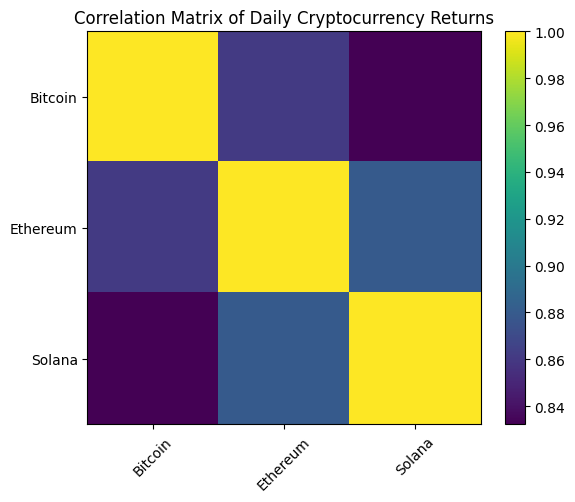

In [23]:
plt.figure(figsize=(6,5))

plt.imshow(correlation_matrix, interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=45)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Matrix of Daily Cryptocurrency Returns")

# SAVE HERE
plt.savefig(
    "figures/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

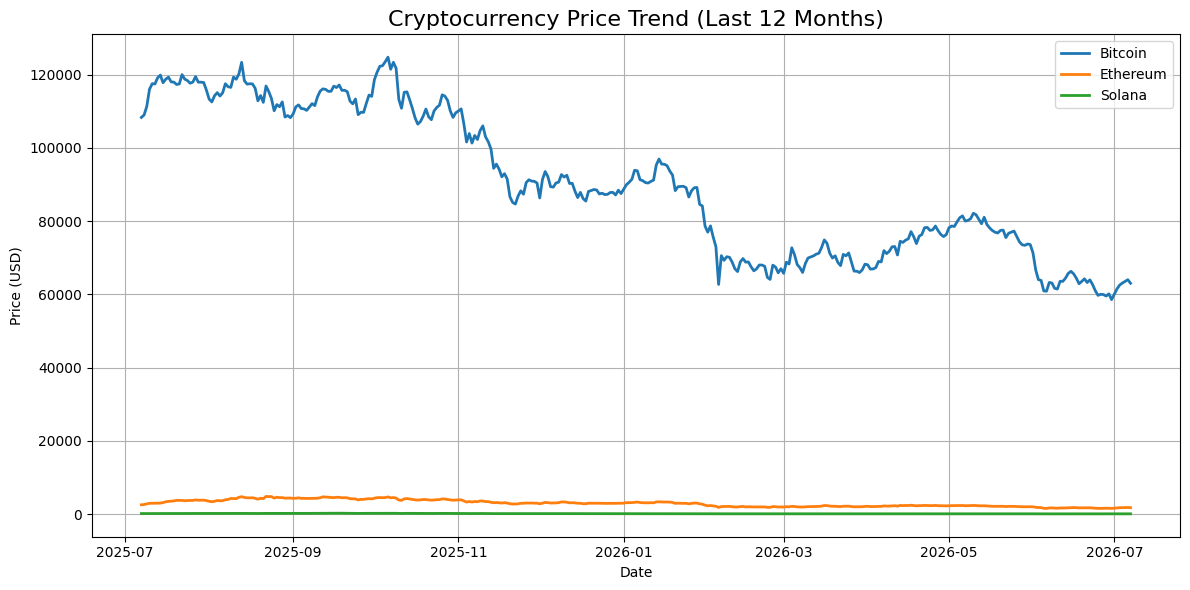

In [24]:
#Price Trend

plt.figure(figsize=(12,6))

for name, data in crypto_data.items():
    plt.plot(data.index, data["Close"], linewidth=2, label=name)

plt.title("Cryptocurrency Price Trend (Last 12 Months)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

# SAVE HERE
plt.savefig(
    "figures/price_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

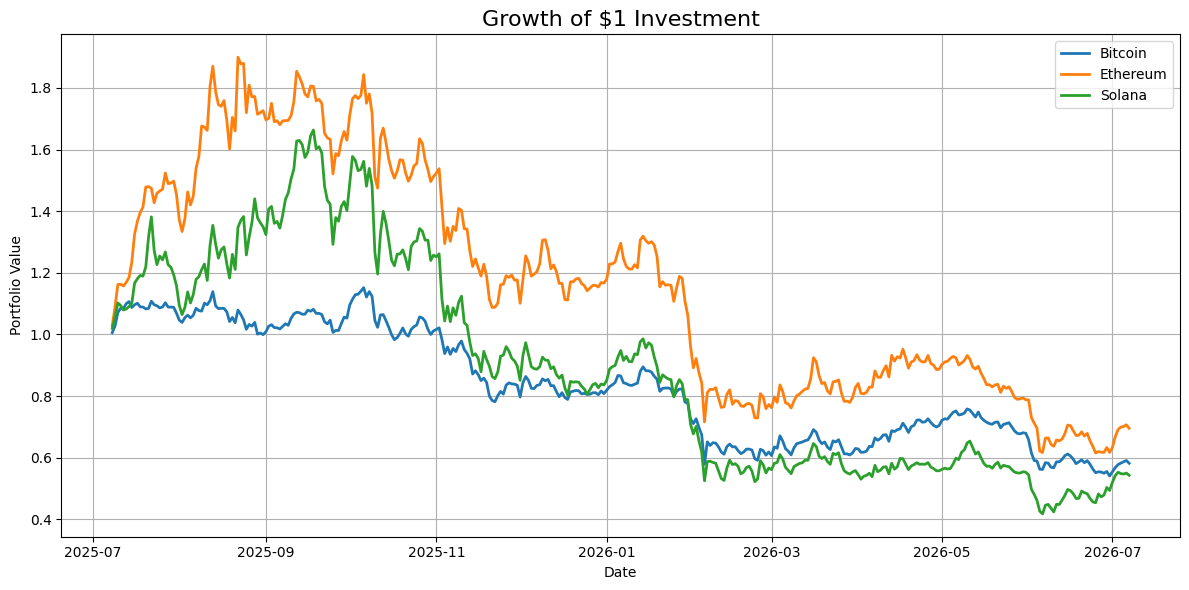

In [25]:
#Cumulative Return(Growth of $1)

plt.figure(figsize=(12,6))

for name, returns in crypto_returns.items():

    cumulative = (1 + returns).cumprod()

    plt.plot(cumulative.index,
             cumulative,
             linewidth=2,
             label=name)

plt.title("Growth of $1 Investment", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()

plt.grid(True)

# SAVE HERE
plt.savefig(
    "figures/Growth of $1 Investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

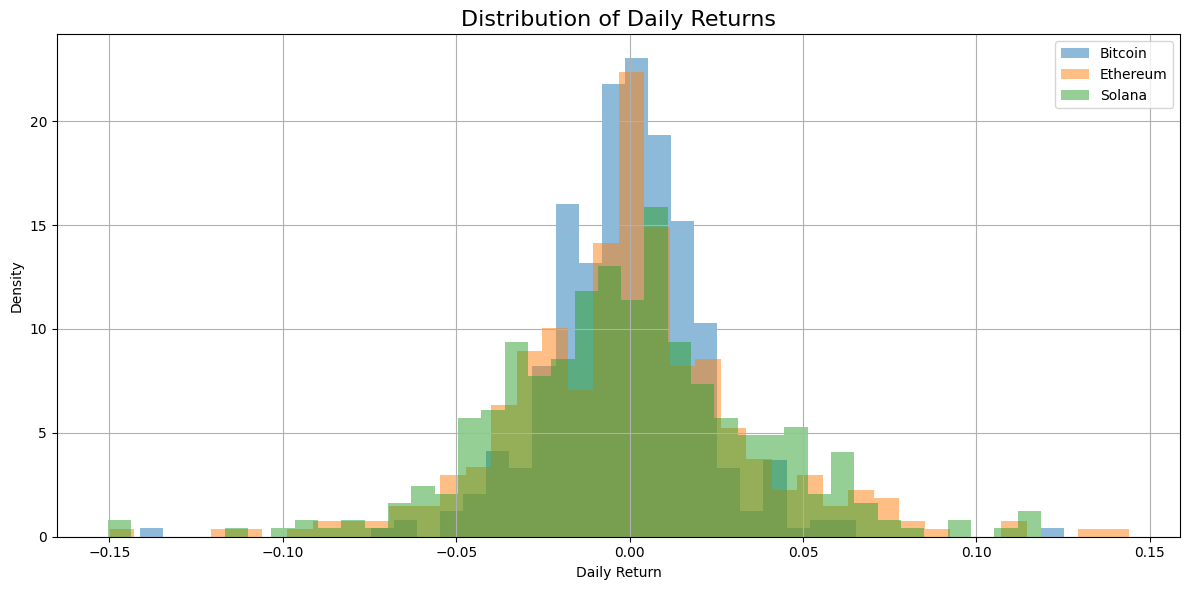

In [26]:
#Return Distribution

plt.figure(figsize=(12,6))

for name, returns in crypto_returns.items():

    plt.hist(
        returns,
        bins=40,
        alpha=0.5,
        density=True,
        label=name
    )

plt.title("Distribution of Daily Returns", fontsize=16)

plt.xlabel("Daily Return")

plt.ylabel("Density")

plt.legend()

plt.grid(True)

# SAVE HERE
plt.savefig(
    "figures/Distribution of Daily Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

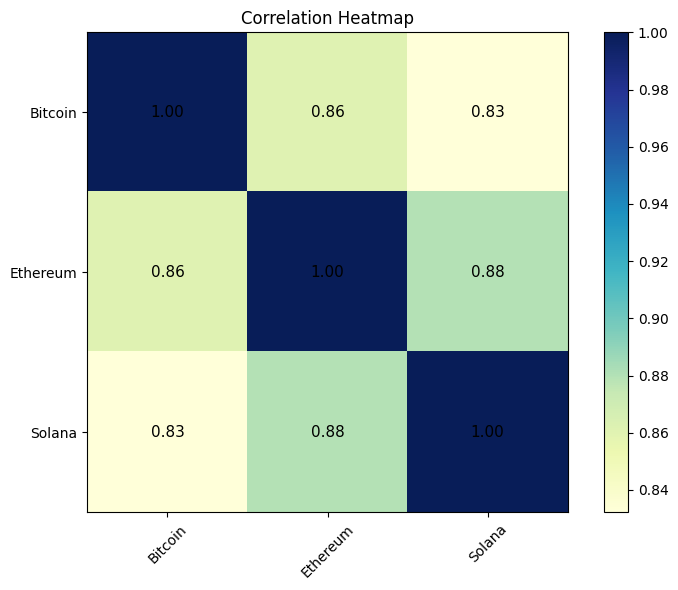

In [27]:
#Correlation Heatmap

returns_df = pd.DataFrame(crypto_returns)

corr = returns_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr,
           cmap="YlGnBu",
           interpolation="nearest")

plt.colorbar()

plt.xticks(
    np.arange(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    np.arange(len(corr.columns)),
    corr.columns
)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.title("Correlation Heatmap")

# SAVE HERE
plt.savefig(
    "figures/Correlation Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

In [28]:
#Risk vs Return Scatter Plot

risk = []

annual_return = []

for name, returns in crypto_returns.items():

    annual_return.append(
        returns.mean()*252*100
    )

    risk.append(
        returns.std()*np.sqrt(252)*100
    )

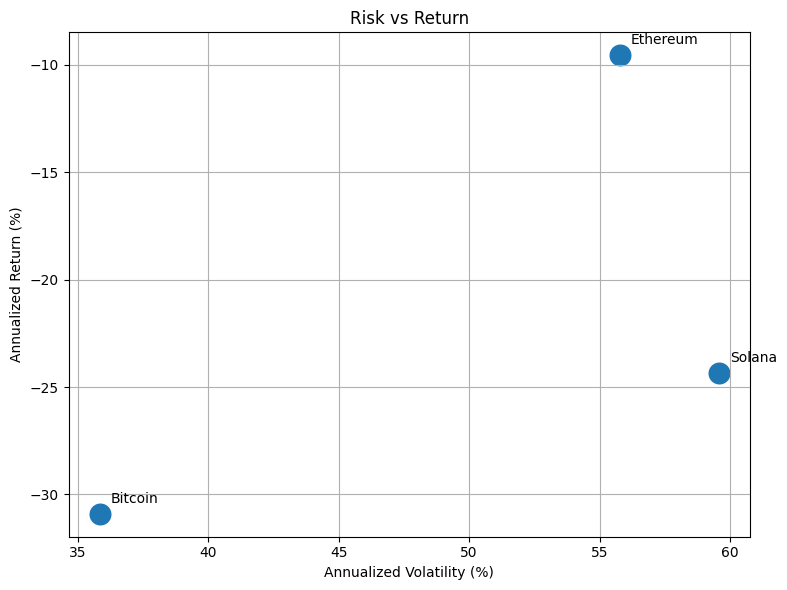

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    risk,
    annual_return,
    s=220
)

for i, name in enumerate(crypto_returns.keys()):

    plt.annotate(
        name,
        (risk[i], annual_return[i]),
        xytext=(8,8),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility (%)")

plt.ylabel("Annualized Return (%)")

plt.title("Risk vs Return")

plt.grid(True)

# SAVE HERE
plt.savefig(
    "figures/Risk vs Return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()